<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Getaround_%28Europe%29.png" alt="Image Gauche" style="width: 100px; height: auto;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Getaround_%28Europe%29.png" alt="Image Gauche" style="width: 100px; height: auto;">
    <div style="text-align: center;">
        <h1>
            <span style="font-weight: bold; color: #A11A99; text-decoration: underline;">
                Getaround_first_exploration
            </span>
        </h1>
    </div>
    <img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Getaround_%28Europe%29.png" alt="Image Droite" style="width: 100px; height: auto;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Getaround_%28Europe%29.png" alt="Image Gauche" style="width: 100px; height: auto;">
</div>


## 🧠 Introduction – Buffer Delay Impact Analysis

To support strategic decisions around implementing a minimum delay between two consecutive rentals,  
we conducted a comprehensive analysis using Getaround's historical rental data.  
This analysis is structured around **seven key focus areas**, each addressing a critical aspect of the problem:

1. **📊 Frequency and severity of checkout delays**  
   _How common are late returns, and how long do they typically last?_

2. **⏱️ Distribution of delays**  
   _Are delays mostly short, or are there significant outliers?_

3. **🔀 Check-in method comparison (Connect vs Mobile)**  
   _Do Connect rentals behave differently from traditional Mobile check-ins?_

4. **⚠️ Critical overlap cases**  
   _How many delays actually interfere with the next rental?_

5. **📉 Impact of different buffer thresholds**  
   _What share of rentals would be excluded depending on the chosen minimum time between bookings?_

6. **✅ Effectiveness of buffer in solving critical overlaps**  
   _How many high-friction cases would a buffer help prevent?_

7. **🚫 Indirect impact on cancellations**  
   _Do short gaps between bookings correlate with canceled rentals?_

---

Each of these points contributes to understanding the **trade-off between customer satisfaction and rental availability**.  
Our goal is to provide **data-driven insights** to help determine:

- The **optimal buffer threshold** (e.g. 15, 30, 60, 120 minutes…)
- Whether the rule should apply to **all rentals**, or only to **Connect rentals**.



# 0. 📥 Imports and data retrieval

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
data = pd.read_excel("../src/get_around_delay_analysis.xlsx", sheet_name="rentals_data")

In [4]:
# Transform in dataframe
df = pd.DataFrame(data)

In [5]:
# Some quick data visualizations
print(df.head(5))
print(df.shape)

   rental_id  car_id checkin_type     state  delay_at_checkout_in_minutes  \
0     505000  363965       mobile  canceled                           NaN   
1     507750  269550       mobile     ended                         -81.0   
2     508131  359049      connect     ended                          70.0   
3     508865  299063      connect  canceled                           NaN   
4     511440  313932       mobile     ended                           NaN   

   previous_ended_rental_id  time_delta_with_previous_rental_in_minutes  
0                       NaN                                         NaN  
1                       NaN                                         NaN  
2                       NaN                                         NaN  
3                       NaN                                         NaN  
4                       NaN                                         NaN  
(21310, 7)


In [6]:
# Simplification of column names

df = df.rename(columns={"checkin_type":"type",
                        "delay_at_checkout_in_minutes":"delay",
                        "previous_ended_rental_id":"prev_id",
                        "time_delta_with_previous_rental_in_minutes":"time_delta"})

# 1. 📊 Frequency and severity of checkout delays

In [7]:
# Filter: keep only completed rentals with a non-null delay value
df_delay = df[(df["state"] == "ended") & (df["delay"].notna())]

# Keep only positive delays
df_positive_delays = df_delay[df_delay["delay"] > 0]

# Descriptive statistics for positive delays
print("📊 Descriptive statistics for checkout delays (positive values only):")
print(df_positive_delays["delay"].describe())

# Additional metrics
print("\n🔢 Additional delay indicators:")
print(f"Total number of rentals: {len(df)}")
print(f"Number of rentals with a positive delay: {len(df_positive_delays)}")
print(f"Share of rentals with delay: {100 * len(df_positive_delays) / len(df):.2f} %")

# Distribution by severity thresholds
thresholds = [5, 15, 30, 60, 120]
for t in thresholds:
    count = (df_positive_delays["delay"] > t).sum()
    percentage = 100 * count / len(df)
    print(f"> Delays > {t} minutes: {count} rentals ({percentage:.2f} %)")


📊 Descriptive statistics for checkout delays (positive values only):
count     9404.000000
mean       201.791472
std       1243.645804
min          1.000000
25%         19.000000
50%         53.000000
75%        131.000000
max      71084.000000
Name: delay, dtype: float64

🔢 Additional delay indicators:
Total number of rentals: 21310
Number of rentals with a positive delay: 9404
Share of rentals with delay: 44.13 %
> Delays > 5 minutes: 8701 rentals (40.83 %)
> Delays > 15 minutes: 7416 rentals (34.80 %)
> Delays > 30 minutes: 6078 rentals (28.52 %)
> Delays > 60 minutes: 4386 rentals (20.58 %)
> Delays > 120 minutes: 2553 rentals (11.98 %)


Checkout delays are significant, with over 44% of rentals experiencing a delay, and nearly 12% exceeding 2 hours. These figures highlight a substantial operational and customer experience impact. From a business perspective, it is therefore essential to consider corrective actions—such as implementing a buffer time between rentals—to reduce friction, enhance user satisfaction, and prevent cancellations due to late returns.

# 2. ⏱️ Distribution of delay

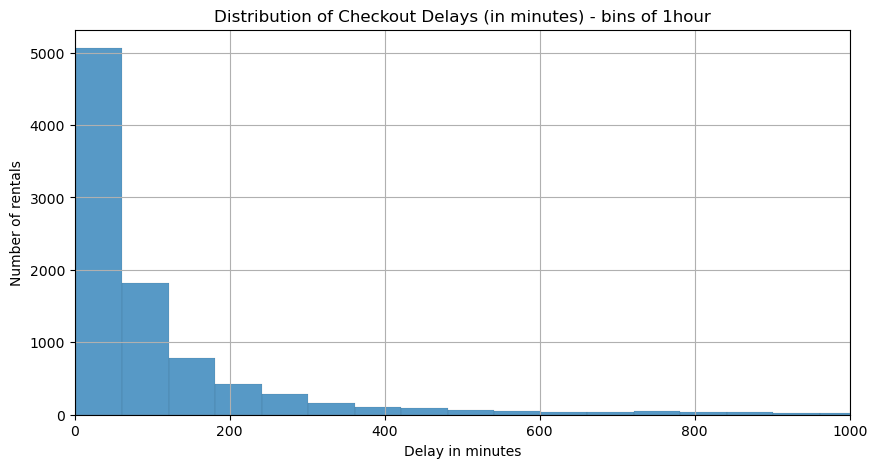

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of positive delays
plt.figure(figsize=(10, 5))
sns.histplot(df_positive_delays["delay"], bins=1184)
plt.title("Distribution of Checkout Delays (in minutes) - bins of 1hour")
plt.xlabel("Delay in minutes")
plt.ylabel("Number of rentals")
plt.xlim(0, 1000)  # limit to focus on the most common range
plt.grid(True)
plt.show()


This distribution confirms that most checkout delays are relatively short—under two hours—yet even such 'short' delays can still negatively impact the customer experience, especially when rentals are scheduled back-to-back.

# 3. 🔀 Check-in method comparison (Connect vs Mobile)

type
mobile     7945
connect    1459
Name: count, dtype: int64


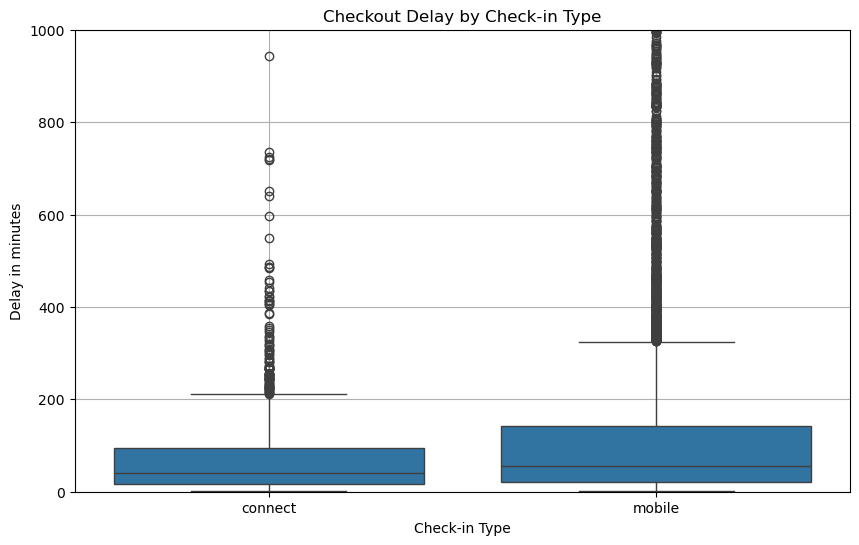


📈 Average delay per check-in type:
type
connect     80.109664
mobile     224.136816
Name: delay, dtype: float64


In [24]:
# Filter dataset to keep only positive delays and non-null checkin types
df_compare = df_positive_delays[df_positive_delays["type"].notna()]

# Check the number of entries per check-in type
print(df_compare["type"].value_counts())

# Boxplot to compare delay distributions between 'connect' and 'mobile'
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_compare, x="type", y="delay")
plt.title("Checkout Delay by Check-in Type")
plt.xlabel("Check-in Type")
plt.ylabel("Delay in minutes")
plt.ylim(0, 1000)  # Zoom on most typical values
plt.grid(True)
plt.show()

# Optionally: compute mean delay per type
mean_delays = df_compare.groupby("type")["delay"].mean()
print("\n📈 Average delay per check-in type:")
print(mean_delays)


The comparison between Connect and Mobile rentals shows that while both check-in types experience delays, Mobile rentals tend to have slightly longer and more variable delays. This could be due to the manual nature of the handoff process. The presence of numerous outliers—especially in Mobile rentals—suggests that certain cases can significantly disrupt the rental flow and heavily skew the mean.

# 4. ⚠️ Critical overlap cases

In [25]:
# Remove rows with missing delay or time delta
df_overlap = df.dropna(subset=["delay", "time_delta"])

# Keep only positive delays
df_overlap = df_overlap[df_overlap["delay"] > 0]

# Filter for cases where delay is greater than the time buffer before the next rental
df_critical_overlap = df_overlap[df_overlap["delay"] > df_overlap["time_delta"]]

print(f"Number of critical cases where delay exceeds time until next rental: {len(df_critical_overlap)}")

# Optional: share of such cases
percentage = 100 * len(df_critical_overlap) / len(df)
print(f"Share of all rentals affected: {percentage:.2f} %")


Number of critical cases where delay exceeds time until next rental: 270
Share of all rentals affected: 1.27 %


Only 270 rentals—representing 1.27% of all cases—had a delay that directly overlapped with the following rental. While this percentage may seem low, these incidents can severely impact user experience. Negative experiences, especially when they lead to missed or delayed rentals, are highly shareable and can quickly damage the brand's reputation through word-of-mouth and social media.

# 5. 📉 Impact of different buffer thresholds

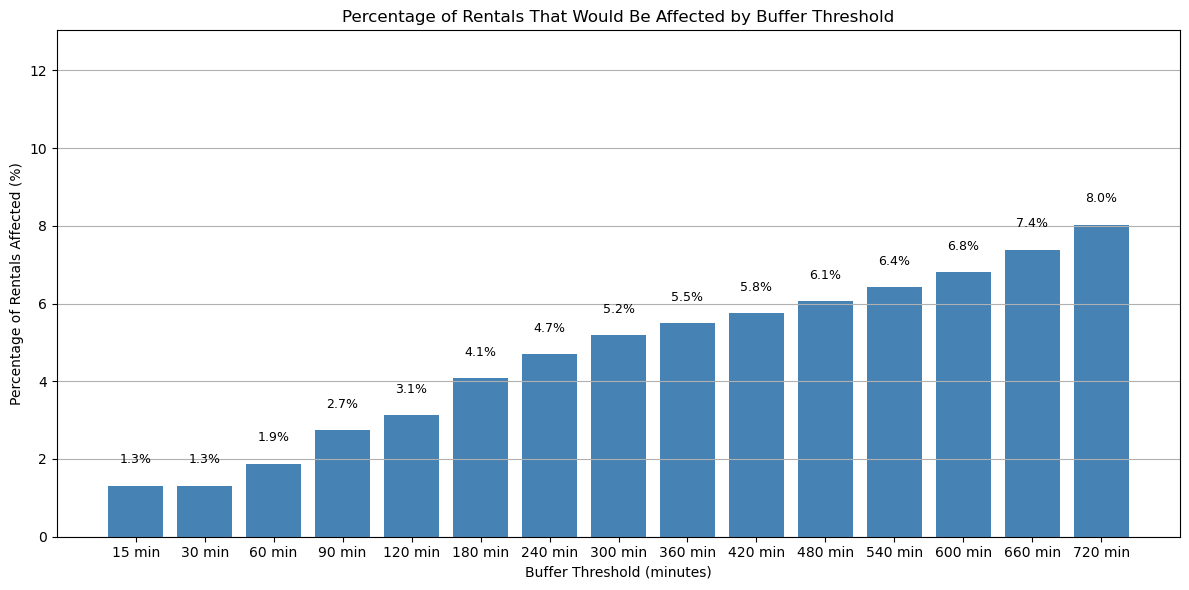

In [41]:
# Drop rows where time_delta is missing
df_buffer = df.dropna(subset=["time_delta"])

# Define buffer thresholds
thresholds = [15, 30, 60, 90, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720]

# Compute % of affected rentals
total_rentals = len(df)
affected_percentages = [(df_buffer["time_delta"] < t).sum() * 100 / total_rentals for t in thresholds]

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar([str(t) + " min" for t in thresholds], affected_percentages, color="steelblue")
plt.title("Percentage of Rentals That Would Be Affected by Buffer Threshold")
plt.xlabel("Buffer Threshold (minutes)")
plt.ylabel("Percentage of Rentals Affected (%)")
plt.ylim(0, max(affected_percentages) + 5)
plt.grid(axis='y')

# Add percentage labels above each bar
for bar, pct in zip(bars, affected_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



As the buffer threshold increases, the percentage of affected rentals rises steadily—reaching over 8% at 12 hours. This confirms that setting the right threshold is critical to minimize disruption while preserving booking flexibility

# 6. ✅ Effectiveness of buffer in solving critical overlaps

In [36]:
# Reuse the critical overlap cases from Point 5
df_critical = df.dropna(subset=["delay", "time_delta"])
df_critical = df_critical[df_critical["delay"] > df_critical["time_delta"]]

# Total number of critical cases
total_critical = len(df_critical)

# Buffer thresholds (in minutes)
thresholds = [15, 30, 60, 90, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720]

# For each threshold, count how many critical cases would be prevented
solved_counts = [(df_critical["time_delta"] < t).sum() for t in thresholds]
solved_percentages = [count * 100 / total_critical for count in solved_counts]


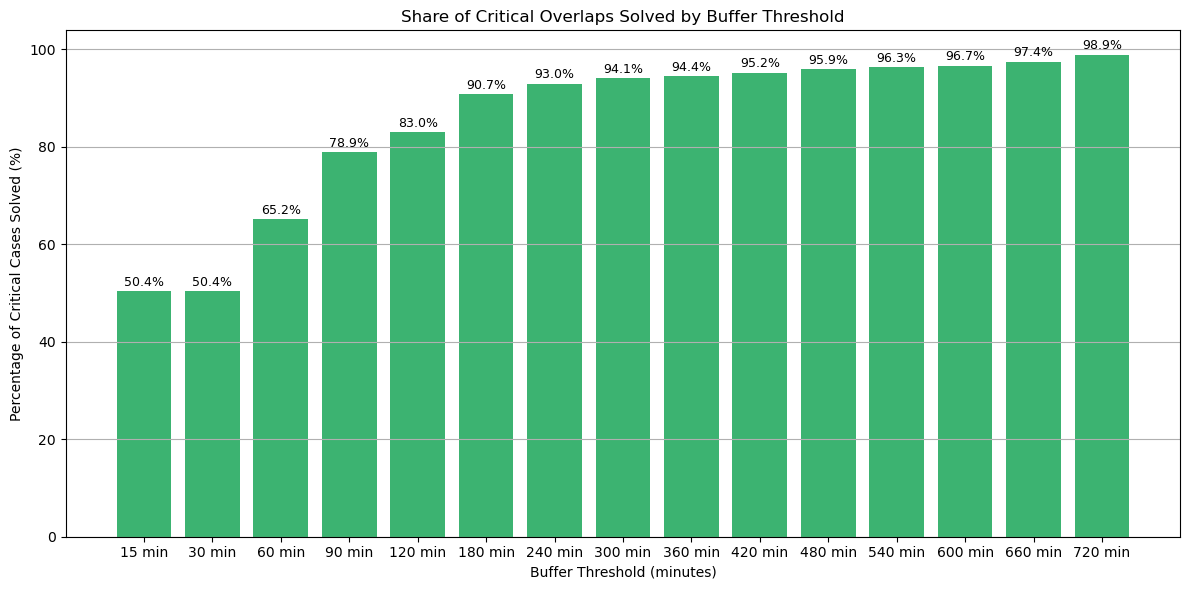

In [ ]:
# Buffer thresholds (in minutes)
thresholds = [15, 30, 60, 90, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720]

plt.figure(figsize=(12, 6))
bars = plt.bar([str(t) + " min" for t in thresholds], solved_percentages, color="mediumseagreen")
plt.title("Share of Critical Overlaps Solved by Buffer Threshold")
plt.xlabel("Buffer Threshold (minutes)")
plt.ylabel("Percentage of Critical Cases Solved (%)")
plt.ylim(0, max(solved_percentages) + 5)
plt.grid(axis='y')

# Add text labels
for bar, pct in zip(bars, solved_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


A 60-minute buffer would resolve approximately 650% of the critical overlap cases. Increasing the buffer further improves coverage, but with diminishing returns. A 6-hour buffer solves almost all known issues (>95%), though at a higher cost in terms of rental availability.

# 7. 🚫 Indirect impact on cancellations

Even though the exact cause of cancellations is not known, we can reasonably hypothesize that some of them may be due to delays from the previous rental—particularly when the time between two bookings is very short (e.g., time_delta < X minutes). This helps estimate the indirect impact of delays on user experience and overall platform performance.

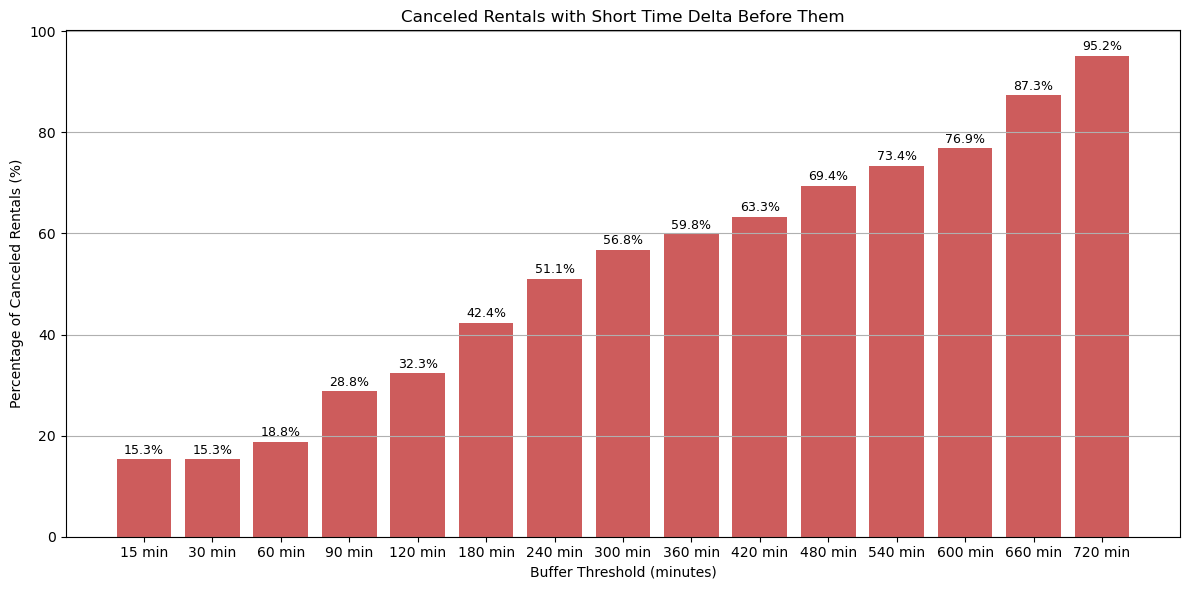

In [40]:
# Filter canceled rentals with known time_delta
df_canceled = df[(df["state"] == "canceled") & (df["time_delta"].notna())]

# Buffer thresholds (in minutes)
thresholds = [15, 30, 60, 90, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720]

# Compute values
canceled_counts = [(df_canceled["time_delta"] < t).sum() * 100 / len(df_canceled) for t in thresholds]

plt.figure(figsize=(12, 6))
bars = plt.bar([str(t) + " min" for t in thresholds], canceled_counts, color="indianred")
plt.title("Canceled Rentals with Short Time Delta Before Them")
plt.xlabel("Buffer Threshold (minutes)")
plt.ylabel("Percentage of Canceled Rentals (%)")
plt.ylim(0, max(canceled_counts) + 5)
plt.grid(axis='y')

# Add annotations
for bar, pct in zip(bars, canceled_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


This chart shows that a growing share of canceled rentals occur when the time gap before them is short. For instance, around 15% of cancellations follow a time delta of less than 30 minutes, and this figure climbs to over 50% within 3 hours. This suggests that tight scheduling—possibly combined with late returns—could be a contributing factor to cancellations.
👉 Implementing a larger buffer could help prevent a significant portion of these cancellations and enhance the overall customer experience.